## Predict on voice files

Loaded model: d:\C_analyzer\NLP_main_clone\nlp_project\models\cnn_multitask.h5

Lamin overall accuracy
Emotion accuracy   : 90.0%
Intensity accuracy : 80.0%
Gender accuracy    : 80.0%

Sein overall accuracy
Emotion accuracy   : 54.5%
Intensity accuracy : 63.6%
Gender accuracy    : 72.7%

SK overall accuracy
Emotion accuracy   : 40.0%
Intensity accuracy : 80.0%
Gender accuracy    : 60.0%

Combined overall accuracy (Lamin + Sein + SK)
Emotion accuracy   : 65.4%
Intensity accuracy : 73.1%
Gender accuracy    : 73.1%

Overall accuracy matrix
        Emotion Intensity Gender
Dataset                         
Lamin     90.0%     80.0%  80.0%
Sein      54.5%     63.6%  72.7%
SK        40.0%     80.0%  60.0%
Overall   65.4%     73.1%  73.1%


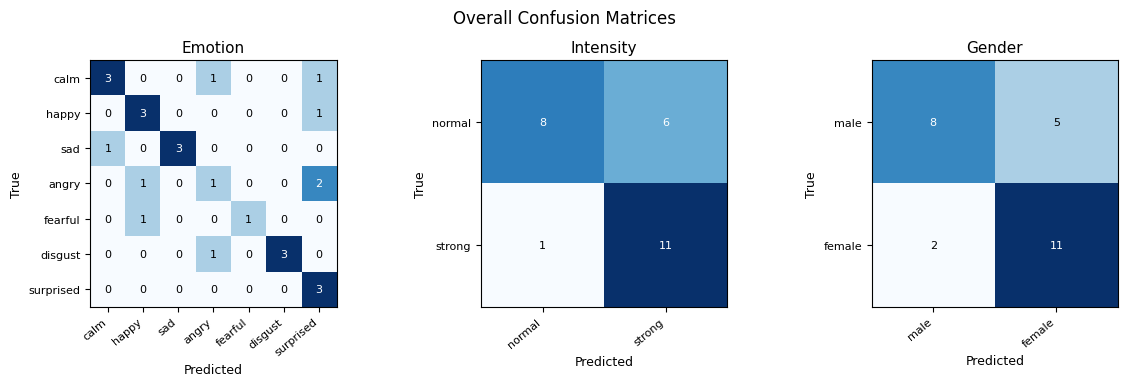

In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

EMOTION_NAMES   = ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
INTENSITY_NAMES = ['normal', 'strong']
GENDER_NAMES    = ['male', 'female']

SAMPLE_RATE = 22050
SAMPLES     = SAMPLE_RATE * 3
N_MELS      = 128
N_FFT       = 2048
HOP_LENGTH  = 512

ROOT_DIR = os.path.abspath('..')
MODEL_PATH      = os.path.join(ROOT_DIR, 'models', 'cnn_multitask.h5')
TEST_DIR        = os.path.join(ROOT_DIR, 'zyne', 'test_file')
LAMIN_DIR       = os.path.join(TEST_DIR, 'Lamin')
SEIN_DIR        = os.path.join(TEST_DIR, 'Sein')
LAMIN_META_PATH = os.path.join(TEST_DIR, 'lamin_test_metadata.csv')
SEIN_META_PATH  = os.path.join(TEST_DIR, 'sein_test_metadata.csv')
SK_AUDIO_DIR    = os.path.join(ROOT_DIR, 'sk', 'sk_test_audios')
SK_META_PATH    = os.path.join(ROOT_DIR, 'sk', 'sk_test_metadata.csv')

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f'Loaded model: {MODEL_PATH}')

def fix_length(y):
    if len(y) > SAMPLES:
        return y[:SAMPLES]
    pad = SAMPLES - len(y)
    return np.pad(y, (pad // 2, pad - pad // 2), 'constant')

def to_3ch(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return np.stack([
        mel_db,
        librosa.feature.delta(mel_db),
        librosa.feature.delta(mel_db, order=2),
    ], axis=-1)

def predict_file(fpath):
    y, sr = librosa.load(fpath, sr=SAMPLE_RATE)
    feat = to_3ch(fix_length(y), sr)[np.newaxis, ...]
    preds = model.predict(feat, verbose=0)

    emo_i = int(np.argmax(preds[0][0]))
    int_i = int(np.argmax(preds[1][0]))
    gen_i = int(np.argmax(preds[2][0]))

    return {
        'pred_emo': EMOTION_NAMES[emo_i],
        'pred_int': INTENSITY_NAMES[int_i],
        'pred_gen': GENDER_NAMES[gen_i],
    }

def normalize_label(value):
    x = str(value).strip().lower()
    return 'surprised' if x == 'suprised' else x

def evaluate_dataset(dataset_name, audio_dir, meta_path, audio_name_builder):
    if not os.path.isdir(audio_dir):
        raise FileNotFoundError(f'Audio folder not found: {audio_dir}')
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f'Metadata not found: {meta_path}')

    rows = []
    missing = []
    df = pd.read_csv(meta_path)

    for _, row in df.iterrows():
        audio_id = str(row['AudioID']).strip()
        fpath = os.path.join(audio_dir, audio_name_builder(audio_id))
        if not os.path.exists(fpath):
            missing.append(audio_id)
            continue

        pred = predict_file(fpath)
        rows.append({
            'dataset': dataset_name,
            'true_emo': normalize_label(row['Emotion']),
            'true_int': normalize_label(row['Intensity']),
            'true_gen': normalize_label(row['Gender']),
            'pred_emo': pred['pred_emo'],
            'pred_int': pred['pred_int'],
            'pred_gen': pred['pred_gen'],
        })

    if missing:
        print(f"Missing files for {dataset_name}: {', '.join(missing)}")

    return rows

def compute_stats(rows):
    if not rows:
        return None

    true_emo = np.array([r['true_emo'] for r in rows])
    pred_emo = np.array([r['pred_emo'] for r in rows])
    true_int = np.array([r['true_int'] for r in rows])
    pred_int = np.array([r['pred_int'] for r in rows])
    true_gen = np.array([r['true_gen'] for r in rows])
    pred_gen = np.array([r['pred_gen'] for r in rows])

    return {
        'emotion_acc': float(np.mean(true_emo == pred_emo)),
        'intensity_acc': float(np.mean(true_int == pred_int)),
        'gender_acc': float(np.mean(true_gen == pred_gen)),
        'true_emo': true_emo, 'pred_emo': pred_emo,
        'true_int': true_int, 'pred_int': pred_int,
        'true_gen': true_gen, 'pred_gen': pred_gen,
    }

def draw_cm(ax, cm, labels, title):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    threshold = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > threshold else 'black', fontsize=8)
    return im

dataset_specs = [
    ('Lamin', LAMIN_DIR, LAMIN_META_PATH, lambda x: f'{x}.wav'),
    ('Sein', SEIN_DIR, SEIN_META_PATH, lambda x: f'{x}.wav'),
    ('SK', SK_AUDIO_DIR, SK_META_PATH, lambda x: f'audio{x}.wav'),
]

dataset_rows = {}
for ds_name, ds_audio_dir, ds_meta_path, audio_builder in dataset_specs:
    dataset_rows[ds_name] = evaluate_dataset(ds_name, ds_audio_dir, ds_meta_path, audio_builder)

all_rows = []
for ds_name in ('Lamin', 'Sein', 'SK'):
    all_rows.extend(dataset_rows[ds_name])

accuracy_table_rows = []
for ds_name in ('Lamin', 'Sein', 'SK'):
    stats = compute_stats(dataset_rows[ds_name])
    if stats is None:
        continue
    print(f'\n{ds_name} overall accuracy')
    print(f"Emotion accuracy   : {stats['emotion_acc']:.1%}")
    print(f"Intensity accuracy : {stats['intensity_acc']:.1%}")
    print(f"Gender accuracy    : {stats['gender_acc']:.1%}")
    accuracy_table_rows.append({
        'Dataset': ds_name,
        'Emotion': stats['emotion_acc'],
        'Intensity': stats['intensity_acc'],
        'Gender': stats['gender_acc'],
    })

overall_stats = compute_stats(all_rows)
if overall_stats is not None:
    print('\nCombined overall accuracy (Lamin + Sein + SK)')
    print(f"Emotion accuracy   : {overall_stats['emotion_acc']:.1%}")
    print(f"Intensity accuracy : {overall_stats['intensity_acc']:.1%}")
    print(f"Gender accuracy    : {overall_stats['gender_acc']:.1%}")
    accuracy_table_rows.append({
        'Dataset': 'Overall',
        'Emotion': overall_stats['emotion_acc'],
        'Intensity': overall_stats['intensity_acc'],
        'Gender': overall_stats['gender_acc'],
    })

accuracy_df = pd.DataFrame(accuracy_table_rows).set_index('Dataset')
print('\nOverall accuracy matrix')
print((accuracy_df * 100).round(1).astype(str) + '%')

if overall_stats is not None:
    emo_cm = confusion_matrix(overall_stats['true_emo'], overall_stats['pred_emo'], labels=EMOTION_NAMES)
    int_cm = confusion_matrix(overall_stats['true_int'], overall_stats['pred_int'], labels=INTENSITY_NAMES)
    gen_cm = confusion_matrix(overall_stats['true_gen'], overall_stats['pred_gen'], labels=GENDER_NAMES)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    draw_cm(axes[0], emo_cm, EMOTION_NAMES, 'Emotion')
    draw_cm(axes[1], int_cm, INTENSITY_NAMES, 'Intensity')
    draw_cm(axes[2], gen_cm, GENDER_NAMES, 'Gender')
    fig.suptitle('Overall Confusion Matrices', fontsize=12)
    fig.tight_layout()
    plt.show()